In [1]:
import pandas as pd
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_train_merged = pd.read_csv('data/train_merged.csv')
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")

In [2]:
df_train = df_train.drop("id", axis=1)
df_test = df_test.drop("id", axis=1)

In [6]:
def add_tire_life_columns(df):
    max_tire_life = {
        "MEDIUM": 40,
        "HARD": 55,
        "SOFT": 30,
        "INTERMEDIATE": 25,
        "WET": 20
    }

    df["MaxTireLife"] = df["Compound"].map(max_tire_life)

    df["TireRemainingLife"] = (
        df["MaxTireLife"] - df["TyreLife"]
    ).clip(lower=0)
    df["TireAgePct"] = (
    df["TyreLife"] / df["MaxTireLife"]).clip(0, 1)
    df["TireRemainingPct"] = (df["TireRemainingLife"] / df["MaxTireLife"]).clip(0, 1)
    

    return df

def add_laps_for_each_race(df):
    df["RaceLaps"] = (
    df["LapNumber"] / (df["RaceProgress"])
).round()
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df


def prev_position_calcute(df):
    df["Prev_Position"] = df["Position"] + df["Position_Change"]
    return df


def get_trend_data(df):
    df["LapTimeAvg_3"] = (
        df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    return df


def set_fe(df):
    df = add_tire_life_columns(df)
    df = add_laps_for_each_race(df)
    df= prev_position_calcute(df)
    df = get_trend_data(df)
    return df

In [7]:
def calculate_race_progress(df):
    condition = (df["Race"] == "Pre-Season Testing") & (
        (df["RaceLaps"] < 31) | (df["RaceLaps"] > 78)
    )

    # Keep rows that do NOT match the condition
    df = df[~condition] 
    F1_RACE_LAPS = {
        "Bahrain Grand Prix": 57,
        "Saudi Arabian Grand Prix": 50,
        "Australian Grand Prix": 58,
        "Azerbaijan Grand Prix": 51,
        "Miami Grand Prix": 57,
        "Monaco Grand Prix": 78,
        "Spanish Grand Prix": 66,
        "Canadian Grand Prix": 70,
        "Austrian Grand Prix": 71,
        "British Grand Prix": 52,
        "Hungarian Grand Prix": 70,
        "Belgian Grand Prix": 44,
        "Dutch Grand Prix": 72,
        "Italian Grand Prix": 51,
        "Singapore Grand Prix": 62,
        "Japanese Grand Prix": 53,
        "Qatar Grand Prix": 57,
        "United States Grand Prix": 56,
        "Mexico City Grand Prix": 71,
        "São Paulo Grand Prix": 71,
        "Las Vegas Grand Prix": 50,
        "Abu Dhabi Grand Prix": 58,
        }
    mask = df["Race"].isin(F1_RACE_LAPS.keys())

    # Update only matching rows
    df.loc[mask, "RaceLaps"] = df.loc[mask, "Race"].map(F1_RACE_LAPS)
    df["RaceLaps"] = df["Race"].map(F1_RACE_LAPS)
    df["RaceProgress"] = df["LapNumber"] / df["RaceLaps"]
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df

In [8]:
df_external_fe =set_fe(df_external.copy())
df_train_fe =set_fe(df_train.copy())
df_train_merged_fe =set_fe(df_train_merged.copy())
df_test_fe =set_fe(df_test.copy())

In [150]:
df_external_fe =calculate_race_progress(df_external_fe)
df_train_fe =calculate_race_progress(df_train_fe)
df_train_merged_fe =calculate_race_progress(df_train_merged_fe)
df_test_fe =calculate_race_progress(df_test_fe)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6376\4174760921.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["RaceLaps"] = df["Race"].map(F1_RACE_LAPS)
C:\Users\Admin\AppData\Local\Temp\ipykernel_6376\4174760921.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["RaceProgress"] = df["LapNumber"] / df["RaceLaps"]
C:\Users\Admin\AppData\Local\Temp\ipykernel_6376\4174760921.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [ ]:
# df_external_fe =set_fe(df_external_fe)
# df_train_fe =set_fe(df_train_fe)
# df_train_merged_fe =set_fe(df_train_merged_fe)
# df_test_fe =set_fe(df_test_fe)


In [87]:
df_train["Race"].unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix'], dtype=object)

In [86]:
df_external["Race"].value_counts()

Race
Dutch Grand Prix             5486
Hungarian Grand Prix         5357
Monaco Grand Prix            5164
Canadian Grand Prix          5154
Mexico City Grand Prix       5105
Spanish Grand Prix           5054
Austrian Grand Prix          4846
Bahrain Grand Prix           4415
Singapore Grand Prix         4304
United States Grand Prix     4029
Italian Grand Prix           3898
Miami Grand Prix             3822
Australian Grand Prix        3775
Azerbaijan Grand Prix        3664
Emilia Romagna Grand Prix    3568
São Paulo Grand Prix         3435
British Grand Prix           3433
Saudi Arabian Grand Prix     3430
Pre-Season Testing           3371
Abu Dhabi Grand Prix         3346
Japanese Grand Prix          3186
Belgian Grand Prix           3151
Qatar Grand Prix             2987
Las Vegas Grand Prix         2683
Chinese Grand Prix           2072
French Grand Prix             945
Pre-Season Test               918
Pre-Season Track Session      773
Name: count, dtype: int64

In [ ]:
df_external_fe =set_fe(df_external.copy())
df_train_fe =set_fe(df_train.copy())
df_train_merged_fe =set_fe(df_train_merged.copy())
df_test_fe =set_fe(df_test.copy())

In [ ]:
df_external_fe =calculate_race_progress(df_external_fe)
df_train_fe =calculate_race_progress(df_train_fe)
df_train_merged_fe =calculate_race_progress(df_train_merged_fe)
df_test_fe =calculate_race_progress(df_test_fe)

In [151]:
df_external_fe.nunique().sort_index()

Compound                      5
Cumulative_Degradation    81360
Driver                       31
LapNumber                    78
LapTime (s)               40779
LapTimeAvg_3              74944
LapTime_Delta             54084
LapsRemaining                80
MaxTireLife                   5
Normalized_TyreLife        1340
PitNextLap                    2
PitStop                       2
Position                     20
Position_Change              37
Prev_Position                20
Race                         28
RaceLaps                     14
RaceProgress                734
Stint                         8
TireAgePct                  130
TireRemainingLife            55
TireRemainingPct            130
TyreLife                     78
Year                          4
dtype: int64

In [124]:
df_train.nunique().sort_index()

Compound                       5
Cumulative_Degradation    142701
Driver                       887
LapNumber                     78
LapTime (s)                37719
LapTime_Delta              57532
PitNextLap                     2
PitStop                        2
Position                      20
Position_Change               37
Race                          26
RaceProgress                1898
Stint                          8
TyreLife                      78
Year                           4
dtype: int64

In [125]:
df_test.nunique().sort_index()

Compound                      5
Cumulative_Degradation    86823
Driver                      801
LapNumber                    77
LapTime (s)               30286
LapTime_Delta             40673
PitStop                       2
Position                     20
Position_Change              37
Race                         26
RaceProgress               1556
Stint                         8
TyreLife                     77
Year                          4
dtype: int64

In [126]:
df_external_fe[df_external_fe["Race"]=="Pre-Season Testing" ]["RaceLaps"].value_counts()

RaceLaps
52.0    881
76.0    856
78.0    744
77.0    320
72.0    184
71.0    178
75.0     62
70.0     61
46.0     45
32.0     31
9.0       9
Name: count, dtype: int64

In [128]:
print(df_train_merged_fe[(df_train_merged_fe["Race"]=="Pre-Season Testing") & ((df_train_merged_fe["RaceLaps"]<31) | (df_train_merged_fe["RaceLaps"]>78))]["RaceLaps"].sum())
print(df_train_merged_fe["RaceLaps"].count())

2558.0
540445


In [ ]:
df_external_fe =set_fe(df_external.copy())
df_train_fe =set_fe(df_train.copy())
df_train_merged_fe =set_fe(df_train_merged.copy())
df_test_fe =set_fe(df_test.copy())

np.int64(540345)

In [ ]:
df_external_fe =set_fe(df_external_fe)
df_train_fe =set_fe(df_train_fe)
df_train_merged_fe =set_fe(df_train_merged_fe)
df_test_fe =set_fe(df_test_fe)

In [42]:
df_external_fe["RaceLaps"].value_counts()

RaceLaps
72.0    23740
76.0    19488
78.0    17779
77.0     8321
71.0     7576
70.0     5227
57.0     3196
52.0     2057
50.0     1707
51.0     1699
58.0     1610
56.0     1400
75.0     1315
69.0     1062
62.0      971
66.0      857
44.0      792
53.0      604
65.0      520
55.0      220
46.0      131
54.0      105
49.0       97
32.0       93
47.0       89
41.0       82
40.0       79
39.0       77
67.0       67
63.0       62
43.0       41
22.0       40
36.0       34
27.0       25
13.0       25
15.0       24
26.0       23
23.0       23
10.0       19
9.0        18
20.0       17
7.0        16
17.0       16
18.0       15
6.0         6
1.0         2
2.0         2
3.0         2
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt
def plot_avg_lap_number(df):
    race_laps = (
        df.groupby("Race", as_index=False)["LapNumber"].mean()
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 6))
    plt.bar(race_laps["Race"], race_laps["LapNumber"])

    plt.xlabel("Race")
    plt.ylabel("Max LapNumber")
    plt.title("Maximum LapNumber by Race")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [23]:

def plot_max_race_laps(df):
    race_laps = (
        df.groupby("Race", as_index=False)["RaceLaps"]
        .max()
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 6))
    plt.bar(race_laps["Race"], race_laps["RaceLaps"])

    plt.xlabel("Race")
    plt.ylabel("Max RaceLaps")
    plt.title("Maximum RaceLaps by Race")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()



In [24]:
df_external_fe[["Race","RaceLaps"]]

,Race,RaceLaps
0,Abu Dhabi Grand Prix,58.0
1,Abu Dhabi Grand Prix,58.0
2,Abu Dhabi Grand Prix,58.0
3,Abu Dhabi Grand Prix,58.0
4,Abu Dhabi Grand Prix,58.0
...,...,...
101366,United States Grand Prix,72.0
101367,United States Grand Prix,72.0
101368,United States Grand Prix,72.0
101369,United States Grand Prix,72.0


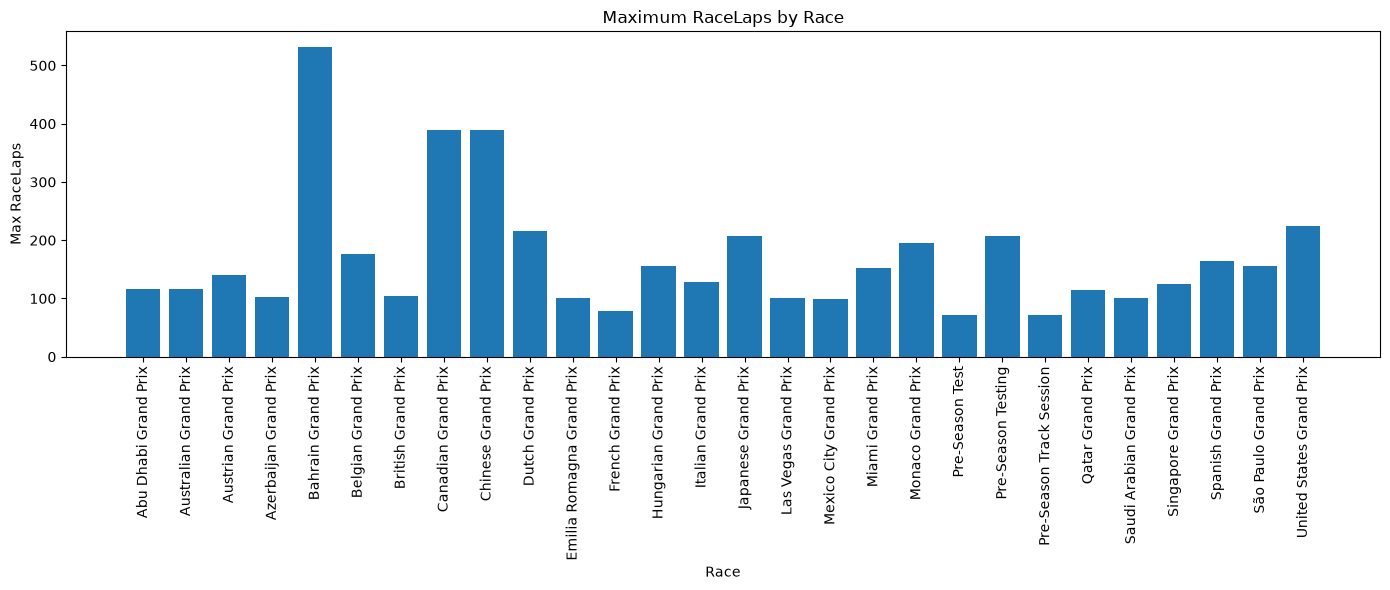

In [25]:
plot_max_race_laps(df_train_merged_fe)


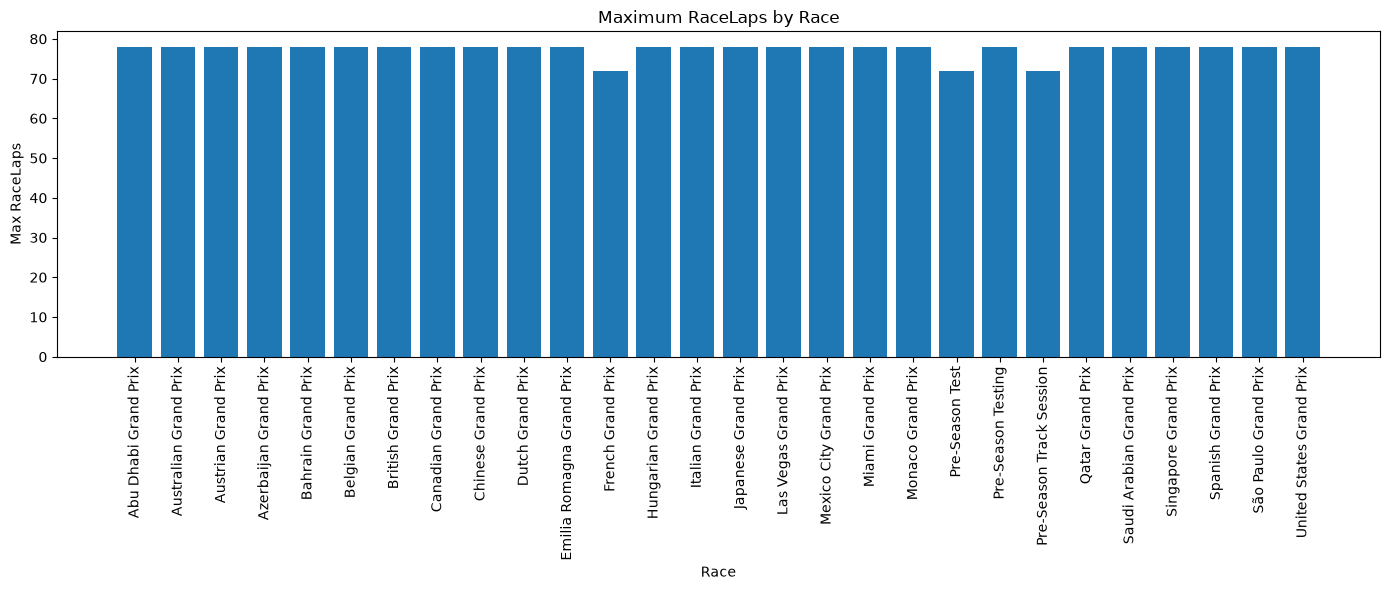

In [26]:
plot_max_race_laps(df_external_fe)

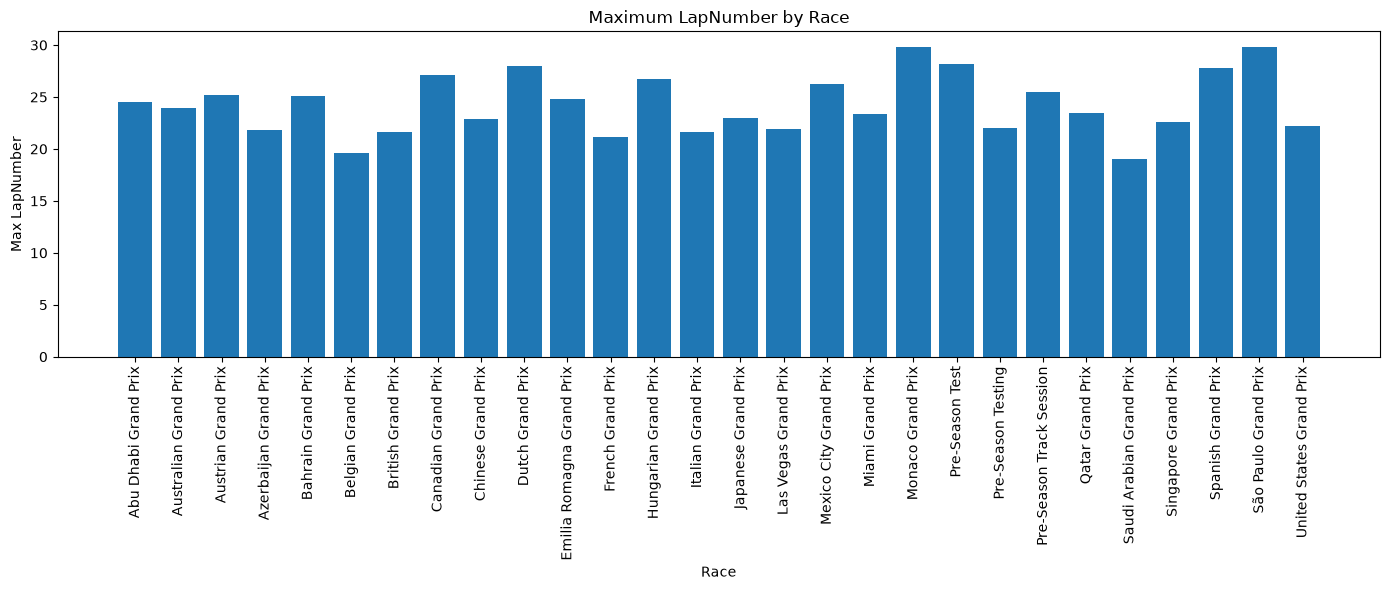

In [27]:
plot_avg_lap_number(df_train_merged_fe)

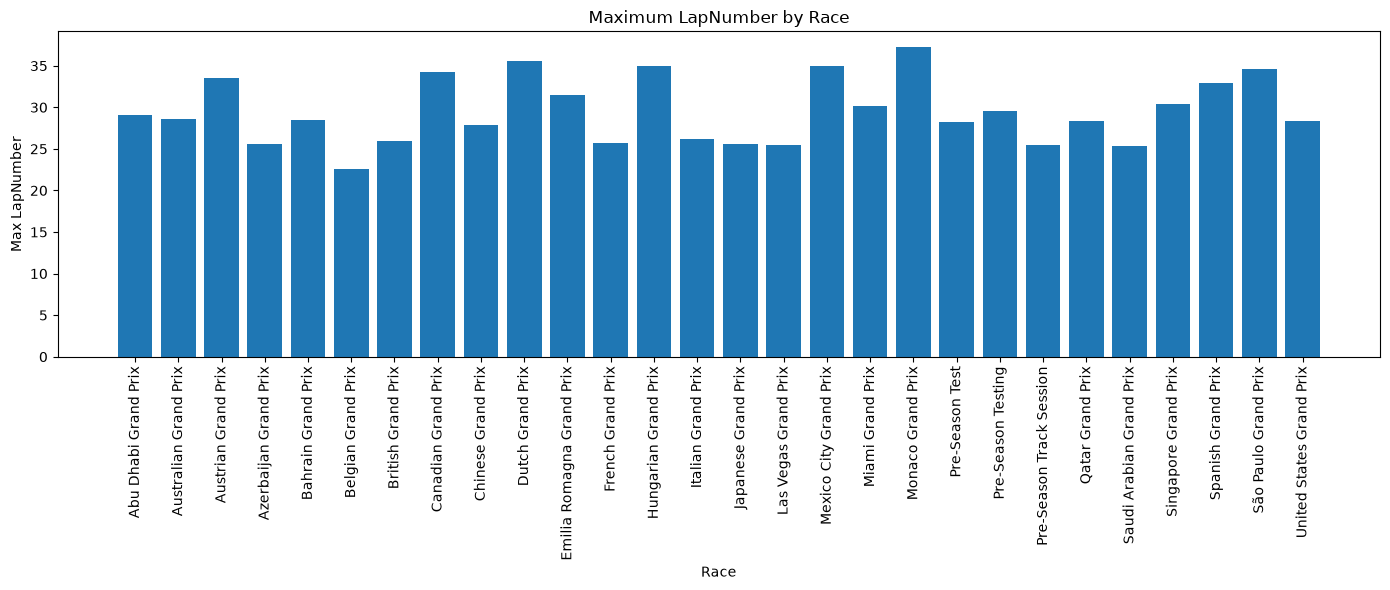

In [28]:
plot_avg_lap_number(df_external_fe)